In [2]:
import pandas as pd
import numpy as np
import scipy
import scanpy as sc
import anndata
import matplotlib
import seaborn as sns
import sklearn
import umap
import sklearn
import sklearn.metrics
import sklearn.ensemble
import sklearn.svm
import sklearn.tree
import sklearn.neighbors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix


In [13]:
file_path = r"C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\scripts\save\test_output\Derived_Embryoid_Bodies_pred_results_20250317_143736.h5ad"
adata = sc.read_h5ad(file_path)


In [ ]:
print (adata)
df = pd.DataFrame(adata.obs)
print("All columns in the dataframe:")
print(df.columns.tolist())
print("\nFirst few rows:")
display(df[['cell_type', 'pred_cell_type', 
           'pred_cell_type_prob_Schwann cell', 'pred_cell_type_prob_blood cell',
           'pred_cell_type_prob_endodermal cell', 'pred_cell_type_prob_endothelial cell',
           'pred_cell_type_prob_epidermal cell', 'pred_cell_type_prob_epithelial cell',
           'pred_cell_type_prob_fibroblast', 'pred_cell_type_prob_intermediate mesodermal cell',
           'pred_cell_type_prob_lateral mesodermal cell', 'pred_cell_type_prob_mesodermal cell',
           'pred_cell_type_prob_neural progenitor cell', 'pred_cell_type_prob_neuron',
           'pred_cell_type_prob_paraxial cell', 'pred_cell_type_prob_primordial germ cell',
           'pred_cell_type_prob_sensory neuron', 'pred_cell_type_prob_somatic stem cell',
           'pred_cell_type_prob_splanchnic mesodermal cell']])


AnnData object with n_obs × n_vars = 140302 × 26232
    obs: 'nCount_RNA', 'nFeature_RNA', 'Size_Factor', 'n.umi', 'scrublet_score', 'scrublet_call', 'sample', 'Ligation_barcode', 'RT_barcode', 'P7_barcode', 'P5_barcode', 'line', 'line_and_time.point', 'time.point', 'perc_mito_umi', 'monocle_cluster', 'sex_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_type', 'is_primary_data', 'cluster', 'Xu_S1B_max_cell_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'pred_cell_type', 'pred_cell_type_prob_Schwann cell', 'pred_cell_type_prob_blood cell', 'pred_cell_type_prob_endodermal cell', 'pred_cell_type_prob_endothelial cell', 'pred_cell_type_prob_epidermal cell', 'pred_cell_typ

,cell_type,pred_cell_type,pred_cell_type_prob_Schwann cell,pred_cell_type_prob_blood cell,pred_cell_type_prob_endodermal cell,pred_cell_type_prob_endothelial cell,pred_cell_type_prob_epidermal cell,pred_cell_type_prob_epithelial cell,pred_cell_type_prob_fibroblast,pred_cell_type_prob_intermediate mesodermal cell,pred_cell_type_prob_lateral mesodermal cell,pred_cell_type_prob_mesodermal cell,pred_cell_type_prob_neural progenitor cell,pred_cell_type_prob_neuron,pred_cell_type_prob_paraxial cell,pred_cell_type_prob_primordial germ cell,pred_cell_type_prob_sensory neuron,pred_cell_type_prob_somatic stem cell,pred_cell_type_prob_splanchnic mesodermal cell
0,endothelial cell,endothelial cell,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,mesodermal cell,mesodermal cell,0.01,0.03,0.00,0.00,0.06,0.08,0.00,0.03,0.04,0.41,0.05,0.00,0.01,0.06,0.12,0.04,0.06
2,lateral mesodermal cell,lateral mesodermal cell,0.00,0.00,0.01,0.01,0.00,0.05,0.04,0.08,0.52,0.01,0.00,0.00,0.00,0.03,0.04,0.13,0.08
3,endodermal cell,endodermal cell,0.01,0.00,0.67,0.00,0.00,0.27,0.01,0.00,0.01,0.01,0.00,0.00,0.00,0.01,0.00,0.00,0.01
4,paraxial cell,sensory neuron,0.02,0.07,0.00,0.03,0.02,0.07,0.04,0.05,0.05,0.06,0.06,0.01,0.05,0.11,0.19,0.05,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166080,mesodermal cell,epithelial cell,0.03,0.04,0.07,0.08,0.02,0.17,0.01,0.04,0.03,0.10,0.08,0.03,0.06,0.02,0.08,0.07,0.07
166081,mesodermal cell,epithelial cell,0.10,0.06,0.04,0.06,0.02,0.13,0.02,0.06,0.01,0.06,0.11,0.03,0.05,0.04,0.05,0.13,0.03
166082,mesodermal cell,mesodermal cell,0.02,0.09,0.07,0.09,0.03,0.10,0.04,0.02,0.02,0.11,0.07,0.04,0.11,0.03,0.04,0.10,0.02
166083,neuron,neuron,0.08,0.02,0.00,0.07,0.00,0.04,0.02,0.04,0.01,0.06,0.09,0.40,0.02,0.05,0.04,0.02,0.04


In [ ]:
# Get probability columns
prob_cols = [col for col in adata.obs.columns if col.startswith('pred_cell_type_prob_')]
cell_types = [col.replace('pred_cell_type_prob_', '') for col in prob_cols]
prob_matrix = np.zeros((adata.n_obs, len(cell_types)))
for i, col in enumerate(prob_cols):
    prob_matrix[:, i] = adata.obs[col].values

adata.obsm['cell_type_probabilities'] = prob_matrix
adata.uns['cell_type_probability_classes'] = cell_types

n = 3  # default but you can change this 

for i in range(adata.n_obs):
    top_indices = np.argsort(prob_matrix[i])[-n:][::-1]
    
    for rank, idx in enumerate(top_indices):
        cell_type = cell_types[idx]
        probability = prob_matrix[i, idx]
        
        adata.obs.loc[adata.obs.index[i], f"top{rank+1}_type"] = cell_type
        adata.obs.loc[adata.obs.index[i], f"top{rank+1}_prob"] = probability

if 'cell_type' in adata.obs.columns: #this can come from the metadata again 
    in_top_n = []
    for i in range(adata.n_obs):
        true_type = adata.obs['cell_type'].iloc[i]
        top_types = [adata.obs[f"top{j+1}_type"].iloc[i] for j in range(n)]
        in_top_n.append(true_type in top_types)
    
    adata.obs['true_in_top_n'] = in_top_n
    top_n_accuracy = sum(in_top_n) / len(in_top_n)
    print(f"Top-{n} accuracy: {top_n_accuracy:.4f}")

adata.obs = adata.obs.drop(columns=prob_cols)

print(f"Top {n} predictions stored in adata.obs columns")

Top-3 accuracy: 0.7524
Full probability matrix stored in adata.obsm['cell_type_probabilities']
Top 3 predictions stored in adata.obs columns


In [ ]:
#see everything in a dataframe
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns in my .obs dataframe
display(adata.obs.head())  # Now this will show all columns

['nCount_RNA', 'nFeature_RNA', 'Size_Factor', 'n.umi', 'scrublet_score', 'scrublet_call', 'sample', 'Ligation_barcode', 'RT_barcode', 'P7_barcode', 'P5_barcode', 'line', 'line_and_time.point', 'time.point', 'perc_mito_umi', 'monocle_cluster', 'sex_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_type', 'is_primary_data', 'cluster', 'Xu_S1B_max_cell_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'pred_cell_type', 'top1_type', 'top1_prob', 'top2_type', 'top2_prob', 'top3_type', 'top3_prob', 'true_in_top_n']


,nCount_RNA,nFeature_RNA,Size_Factor,n.umi,scrublet_score,scrublet_call,sample,Ligation_barcode,RT_barcode,P7_barcode,P5_barcode,line,line_and_time.point,time.point,perc_mito_umi,monocle_cluster,sex_ontology_term_id,donor_id,organism_ontology_term_id,tissue_ontology_term_id,tissue_type,assay_ontology_term_id,disease_ontology_term_id,cell_type_ontology_term_id,self_reported_ethnicity_ontology_term_id,development_stage_ontology_term_id,suspension_type,is_primary_data,cluster,Xu_S1B_max_cell_type,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,pred_cell_type,top1_type,top1_prob,top2_type,top2_prob,top3_type,top3_prob,true_in_top_n
0,1369.0,1046,3.197984,1369.0,0.062500,Singlet,SD34,LIG221,P01-E01,E01,A03,MSC-iPS,MSC-iPS Day 7,Day 7,0.803506,23,PATO:0000384,CVCL_C961,NCBITaxon:9606,UBERON:0014374,organoid,EFO:0030028,PATO:0000461,CL:0000115,unknown,unknown,nucleus,True,23,endothelium,endothelial cell,sci-RNA-seq3,normal,Homo sapiens,male,embryoid body,unknown,unknown,8G_@dyCe`*,endothelial cell,endothelial cell,1.00,splanchnic mesodermal cell,0.00,intermediate mesodermal cell,0.00,True
1,499.0,426,1.165664,499.0,0.117853,Singlet,SD34,LIG225,P01-E01,E01,A03,MSC-iPS,MSC-iPS Day 7,Day 7,0.801603,29,PATO:0000384,CVCL_C961,NCBITaxon:9606,UBERON:0014374,organoid,EFO:0030028,PATO:0000461,CL:0000222,unknown,unknown,nucleus,True,29,craniofacial,mesodermal cell,sci-RNA-seq3,normal,Homo sapiens,male,embryoid body,unknown,unknown,Wz8i5kC^dT,mesodermal cell,mesodermal cell,0.41,sensory neuron,0.12,epithelial cell,0.08,True
2,2022.0,1437,4.723392,2022.0,0.254658,Singlet,SD34,LIG253,P01-E01,E01,A03,MSC-iPS,MSC-iPS Day 7,Day 7,0.346192,11,PATO:0000384,CVCL_C961,NCBITaxon:9606,UBERON:0014374,organoid,EFO:0030028,PATO:0000461,CL:0011010,unknown,unknown,nucleus,True,11,limb,lateral mesodermal cell,sci-RNA-seq3,normal,Homo sapiens,male,embryoid body,unknown,unknown,`<16MFI}S),lateral mesodermal cell,lateral mesodermal cell,0.52,somatic stem cell,0.13,intermediate mesodermal cell,0.08,True
3,1668.0,1231,3.896448,1668.0,0.291667,Singlet,SD34,LIG306,P01-E01,E01,A03,MSC-iPS,MSC-iPS Day 7,Day 7,0.959233,32,PATO:0000384,CVCL_C961,NCBITaxon:9606,UBERON:0014374,organoid,EFO:0030028,PATO:0000461,CL:0000223,unknown,unknown,nucleus,True,32,endoderm,endodermal cell,sci-RNA-seq3,normal,Homo sapiens,male,embryoid body,unknown,unknown,b0pjzew1|Z,endodermal cell,endodermal cell,0.67,epithelial cell,0.27,splanchnic mesodermal cell,0.01,True
4,241.0,223,0.562976,241.0,0.088608,Singlet,SD34,LIG334,P01-E01,E01,A03,MSC-iPS,MSC-iPS Day 7,Day 7,0.414938,17,PATO:0000384,CVCL_C961,NCBITaxon:9606,UBERON:0014374,organoid,EFO:0030028,PATO:0000461,CL:0011007,unknown,unknown,nucleus,True,17,somite,paraxial cell,sci-RNA-seq3,normal,Homo sapiens,male,embryoid body,unknown,unknown,;)xLgf6stF,sensory neuron,sensory neuron,0.19,splanchnic mesodermal cell,0.12,primordial germ cell,0.11,False


In [36]:
# Display subset of columns related to cell type predictions and probabilities
cols_to_show = ['cell_type', 'pred_cell_type'] + [f'top{i}_type' for i in range(1,4)] + [f'top{i}_prob' for i in range(1,4)]
display(adata.obs[cols_to_show].head(20))


,cell_type,pred_cell_type,top1_type,top2_type,top3_type,top1_prob,top2_prob,top3_prob
0,endothelial cell,endothelial cell,endothelial cell,splanchnic mesodermal cell,intermediate mesodermal cell,1.00,0.00,0.00
1,mesodermal cell,mesodermal cell,mesodermal cell,sensory neuron,epithelial cell,0.41,0.12,0.08
2,lateral mesodermal cell,lateral mesodermal cell,lateral mesodermal cell,somatic stem cell,intermediate mesodermal cell,0.52,0.13,0.08
3,endodermal cell,endodermal cell,endodermal cell,epithelial cell,splanchnic mesodermal cell,0.67,0.27,0.01
4,paraxial cell,sensory neuron,sensory neuron,splanchnic mesodermal cell,primordial germ cell,0.19,0.12,0.11
5,primordial germ cell,sensory neuron,sensory neuron,mesodermal cell,primordial germ cell,0.26,0.25,0.16
6,endodermal cell,endodermal cell,endodermal cell,epithelial cell,Schwann cell,0.82,0.13,0.01
7,somatic stem cell,somatic stem cell,somatic stem cell,lateral mesodermal cell,mesodermal cell,0.91,0.08,0.01
8,splanchnic mesodermal cell,intermediate mesodermal cell,intermediate mesodermal cell,splanchnic mesodermal cell,lateral mesodermal cell,0.21,0.19,0.13
9,lateral mesodermal cell,sensory neuron,sensory neuron,lateral mesodermal cell,somatic stem cell,0.18,0.17,0.16


In [31]:

def evaluate_predictions_with_visuals(adata, cell_type_col='cell_type', pred_cell_col='pred_cell_type', 
                                     valid_classes=None, figsize=(12, 10), cmap='RdYlBu'):
    """
    Evaluate classifier performance on an AnnData object and visualize results.
    """
    # Get the ground truth and predictions
    y_true = adata.obs[cell_type_col]
    y_pred = adata.obs[pred_cell_col]
    
    # Convert to pandas Series
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    
    # Drop any rows with NaN in either series
    valid_idx = ~(y_true.isna() | y_pred.isna())
    y_true = y_true[valid_idx]
    y_pred = y_pred[valid_idx]
    
    # Determine valid classes if not provided
    if valid_classes is None:
        valid_classes = sorted(set(y_true) & set(y_pred))
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', 
                        labels=valid_classes, zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', 
                        labels=valid_classes, zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', 
                        labels=valid_classes, zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', 
                          labels=valid_classes, zero_division=0)
    
    # Print summary
    print(f"\nEvaluation Results:")
    print(f"Samples: {len(y_true)}")
    print(f"Classes: {len(valid_classes)}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    
    # Store in adata
    adata.uns["classifier_metrics"] = {
        'accuracy': float(accuracy),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'precision': float(precision),
        'recall': float(recall),
        'num_classes': len(valid_classes),
        'n_samples': len(y_true)
    }
    print(f"Metrics stored in adata.uns['classifier_metrics']")
    
    # Create confusion matrix
    plt.figure(figsize=figsize)
    cm = confusion_matrix(y_true, y_pred, labels=valid_classes)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    ax = sns.heatmap(cm_normalized, annot=False, cmap=cmap, 
                     xticklabels=valid_classes, yticklabels=valid_classes)
    plt.title("Normalized Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Create UMAP visualization
    if 'X_umap' in adata.obsm:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Plot true labels
        scatter1 = ax1.scatter(adata.obsm['X_umap'][:, 0], adata.obsm['X_umap'][:, 1], 
                  c=adata.obs[cell_type_col].astype('category').cat.codes, 
                  cmap=cmap, s=1, alpha=0.7)
        ax1.set_title(f"UMAP - True Cell Types ({cell_type_col})")
        
        # Plot predicted labels
        scatter2 = ax2.scatter(adata.obsm['X_umap'][:, 0], adata.obsm['X_umap'][:, 1], 
                  c=adata.obs[pred_cell_col].astype('category').cat.codes, 
                  cmap=cmap, s=1, alpha=0.7)
        ax2.set_title(f"UMAP - Predicted Cell Types ({pred_cell_col})")
        
        plt.tight_layout()
        plt.show()
    else:
        print("UMAP embeddings not found in adata.obsm['X_umap']. Skipping UMAP visualization.")
    
    results = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall,
        'num_classes': len(valid_classes),
        'n_samples': len(y_true)
    }
    
    return y_pred, y_true, valid_classes, results


Evaluation Results:
Samples: 140302
Classes: 17
Accuracy: 0.4924
Macro F1: 0.4503
Weighted F1: 0.4740
Precision: 0.5432
Recall: 0.4391
Metrics stored in adata.uns['classifier_metrics']


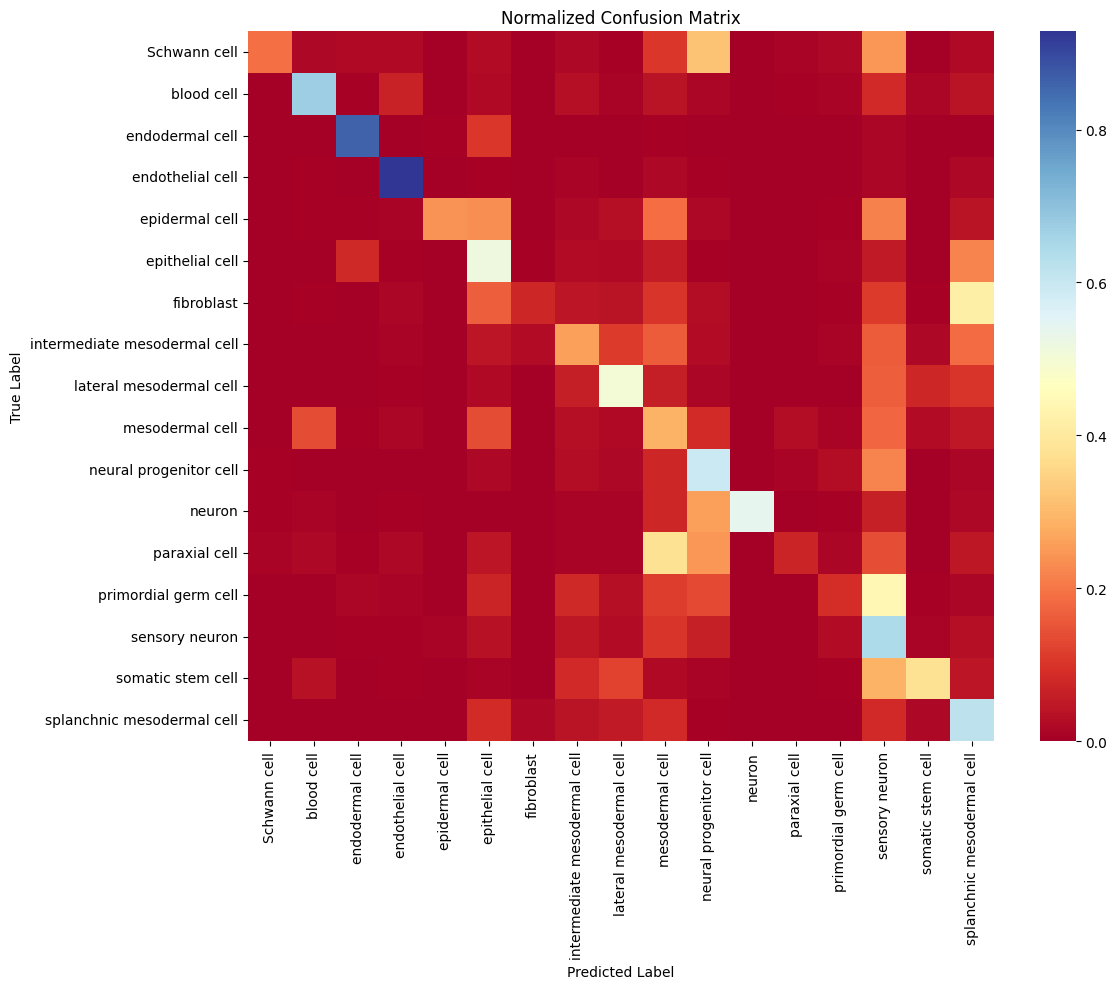

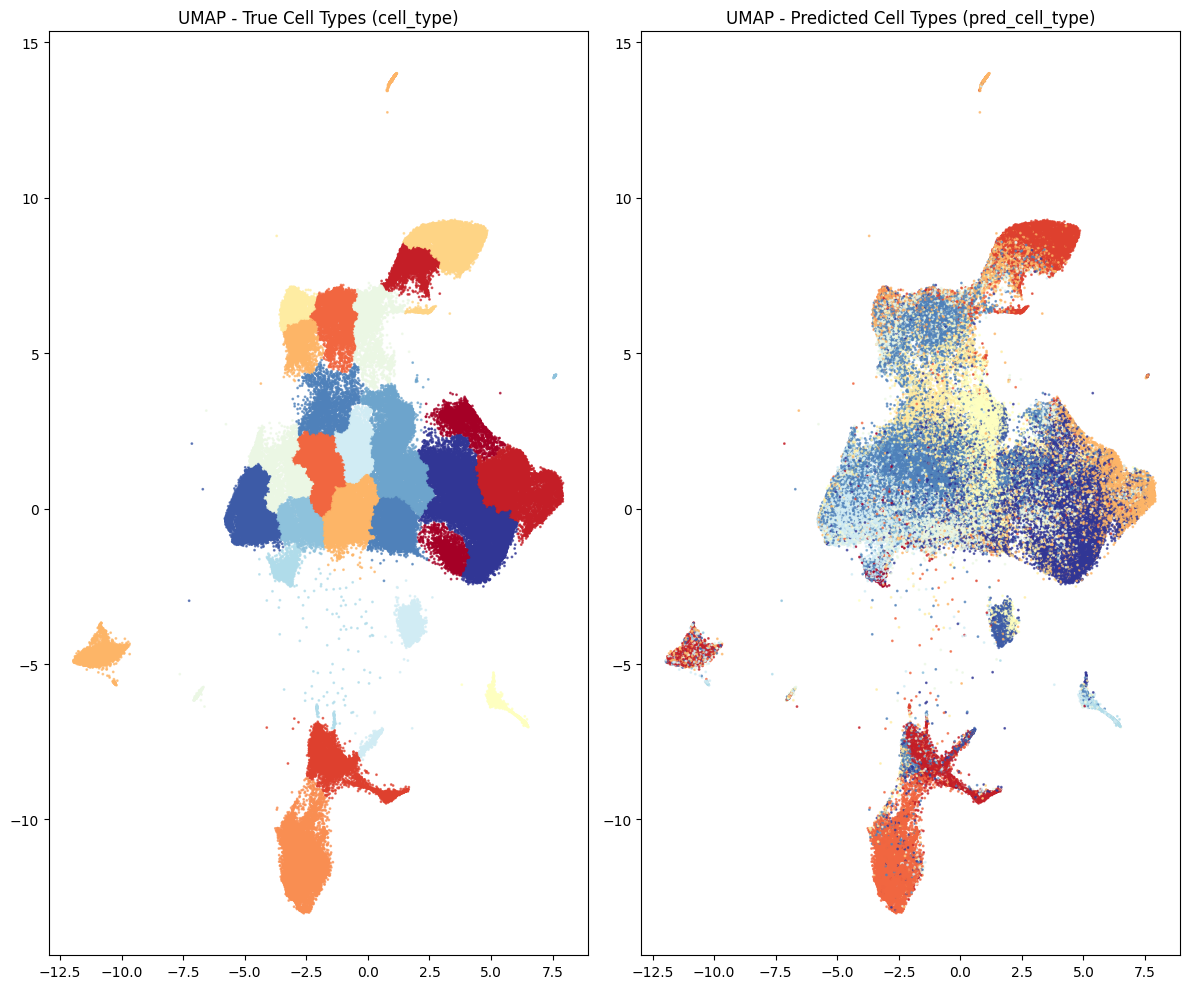

In [32]:
# To evaluate and visualize the predictions
y_pred, y_true, valid_classes, results = evaluate_predictions_with_visuals(adata)

In [33]:
def evaluate_top_classes(adata, n_classes=10, cell_type_col='cell_type', pred_cell_col='pred_cell_type'):
    top_classes = adata.obs[cell_type_col].value_counts()[:n_classes].index.tolist()
    
    mask = adata.obs[cell_type_col].isin(top_classes)
    filtered_adata = adata[mask].copy()
    
    print(f"Filtered to {len(filtered_adata)} cells with the top {n_classes} most frequent classes")
    
    return evaluate_predictions_with_visuals(filtered_adata, 
                                            cell_type_col=cell_type_col,
                                            pred_cell_col=pred_cell_col,
                                            valid_classes=top_classes)

Filtered to 112765 cells with the top 10 most frequent classes

Evaluation Results:
Samples: 112765
Classes: 10
Accuracy: 0.4973
Macro F1: 0.4864
Weighted F1: 0.4958
Precision: 0.5350
Recall: 0.4817
Metrics stored in adata.uns['classifier_metrics']


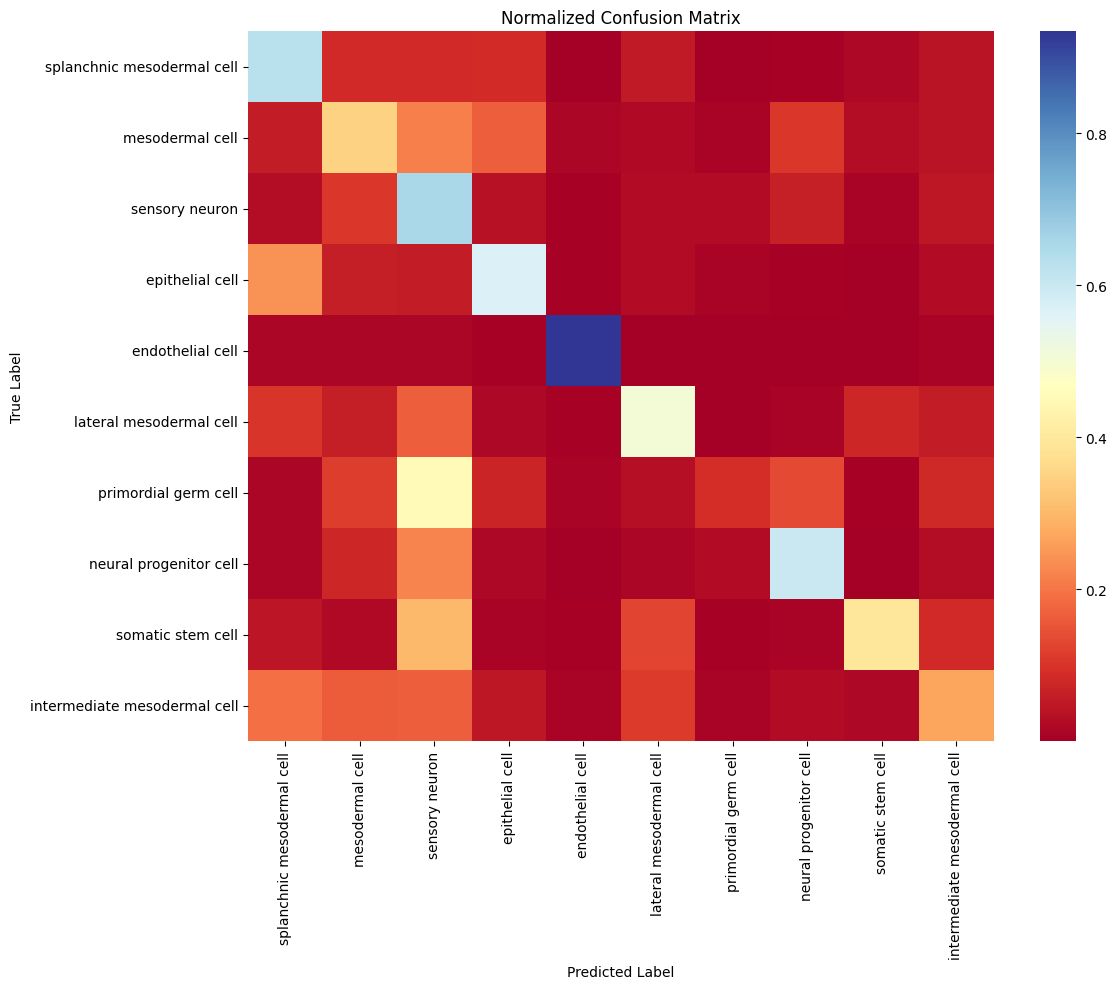

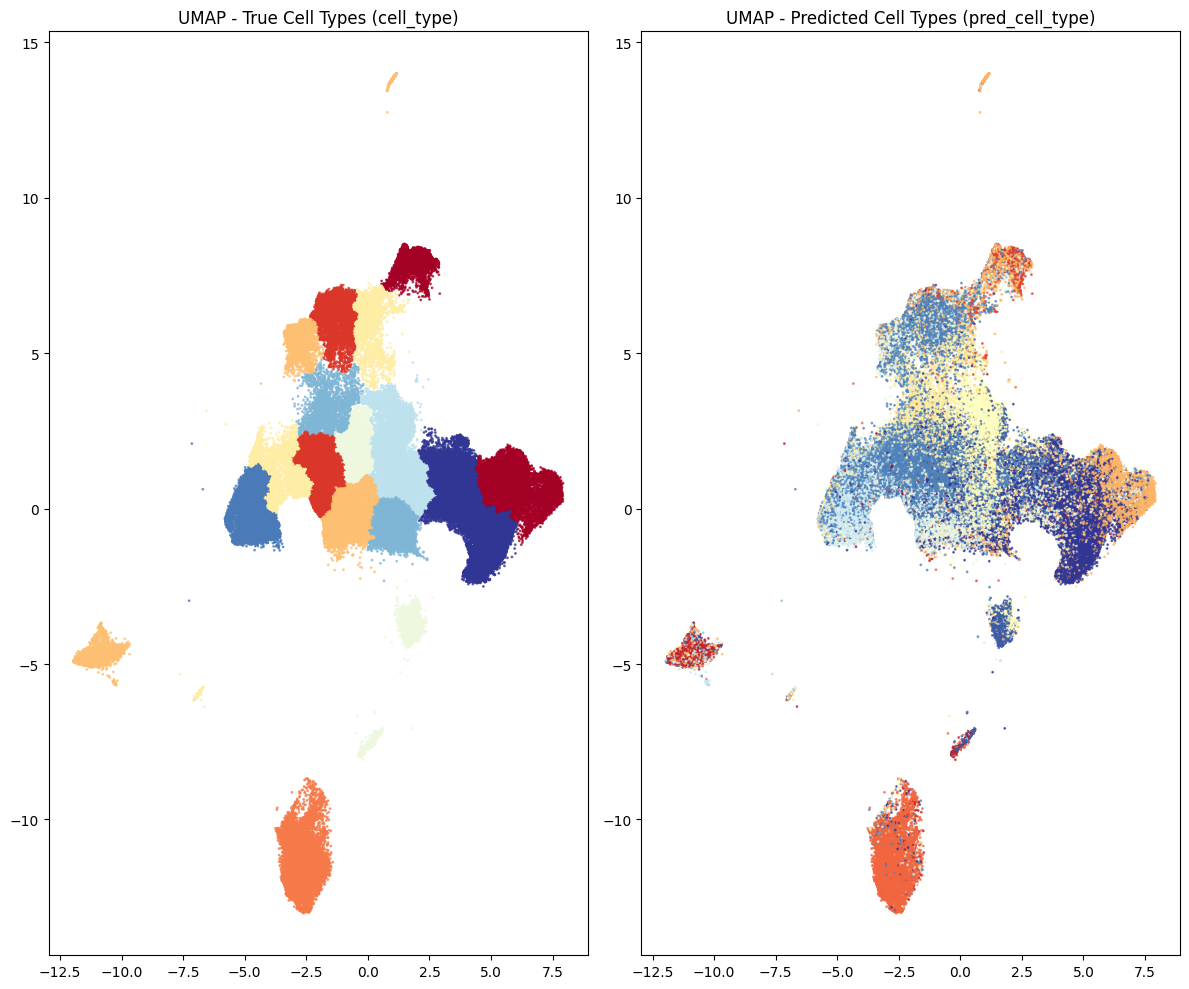

(0                endothelial cell
 1                 mesodermal cell
 2         lateral mesodermal cell
 5                  sensory neuron
 7               somatic stem cell
                    ...           
 166079     neural progenitor cell
 166080            epithelial cell
 166081            epithelial cell
 166082            mesodermal cell
 166084                 blood cell
 Name: pred_cell_type, Length: 112765, dtype: category
 Categories (17, object): ['Schwann cell', 'blood cell', 'endodermal cell', 'endothelial cell', ..., 'primordial germ cell', 'sensory neuron', 'somatic stem cell', 'splanchnic mesodermal cell'],
 0                endothelial cell
 1                 mesodermal cell
 2         lateral mesodermal cell
 5            primordial germ cell
 7               somatic stem cell
                    ...           
 166079            mesodermal cell
 166080            mesodermal cell
 166081            mesodermal cell
 166082            mesodermal cell
 166084        

In [34]:
evaluate_top_classes(adata)